# 2D Variational Autoencoder (VAE) for Cylinder Flow

This notebook demonstrates how to use a **Variational Autoencoder (VAE)** with a convolutional architecture to learn a low-dimensional latent representation of a 2D cylinder flow field using pyLOM.

The workflow consists of the following steps:
1. Load the cylinder flow dataset and subtract the temporal mean.
2. Reshape the data into a 2D spatial grid and create a `pyLOM.NN.Dataset`.
3. Define and train a convolutional VAE (Encoder2D + Decoder2D).
4. Reconstruct the flow field and evaluate the reconstruction accuracy.
5. Export results to ParaView and visualise snapshots.

## Imports

Let's start by importing the required libraries. `pyLOM.NN` provides the neural-network building blocks (architectures, dataset helpers, training pipeline, etc.).

In [1]:
from __future__ import print_function, division

import mpi4py
mpi4py.rc.recv_mprobe = False

import os, numpy as np, torch
import pyLOM, pyLOM.NN

/home/ubuntu/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1774460430.397866  364965 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774460431.308229  364965 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Device selection

`pyLOM.NN.select_device` automatically picks a CUDA GPU if one is available, or falls back to CPU. You can force a specific device by passing `"cpu"` or `"cuda"` explicitly.

In [2]:
device = pyLOM.NN.select_device()  # Automatically selects GPU if available, otherwise CPU
print('Using device:', device)

Using device: cuda


## Hyperparameters

Here we define the architecture and training hyperparameters of the VAE:

| Parameter | Description |
|---|---|
| `nlayers` | Number of convolutional layers in the encoder / decoder |
| `channels` | Base number of feature maps in the first convolutional layer |
| `lat_dim` | Dimensionality of the latent space |
| `beta` | KL-divergence weight (0 = plain autoencoder) |
| `beta_start` / `beta_wmup` | Epoch at which beta annealing starts / warm-up duration |
| `kernel_size` / `padding` | Conv kernel size and zero-padding |
| `nlinear` | Size of the fully-connected bottleneck layer |
| `activations` | Per-layer activation functions |

In [3]:
nlayers     = 5
channels    = 64
lat_dim     = 2
beta        = 0       # 0 → standard autoencoder (no KL penalty)
beta_start  = 0
beta_wmup   = 0
kernel_size = 4
nlinear     = 512
padding     = 1
activations = [pyLOM.NN.relu() for _ in range(nlayers + 2)]

## Paths and results folder

We set the path to the pyLOM dataset file and create a results directory whose name encodes the key hyperparameters (beta and latent dimension) so that multiple runs can coexist.

In [4]:
DATAFILE = 'CYLINDER.h5'
RESUDIR  = 'vae_beta_%.2e_ld_%i' % (beta, lat_dim)

pyLOM.NN.create_results_folder(RESUDIR)
print('Results will be saved in:', RESUDIR)

Folder created: vae_beta_0.00e+00_ld_2
Results will be saved in: vae_beta_0.00e+00_ld_2


## Mesh grid dimensions

The convolutional encoder/decoder operates on 2D spatial grids, so the 1-D point data stored in the pyLOM dataset must be reshaped into `(H, W)` images.

* `(n0h, n0w)` is the **original** grid size as stored in the dataset.
* `(nh, nw)` is the **cropped** size used for training — dimensions are trimmed to the nearest power-of-2-friendly size so that the encoder/decoder strides divide evenly at every layer.

In [5]:
n0h = 449   # original height (rows)
n0w = 199   # original width  (cols)
nh  = 448   # cropped height used for training
nw  = 192   # cropped width  used for training

print(f'Original grid : {n0h} x {n0w}')
print(f'Training grid : {nh} x {nw}')

Original grid : 449 x 199
Training grid : 448 x 192


## Data loading and preprocessing

We load the mesh and the dataset, extract the streamwise velocity `VELOX` and subtract its temporal mean. Mean subtraction is a common pre-processing step that centres the data around zero and lets the autoencoder focus on learning the fluctuating component of the flow.

In [6]:
m    = pyLOM.Mesh.load(DATAFILE)
d    = pyLOM.Dataset.load(DATAFILE, ptable=m.partition_table)

u_x  = d['VELOX']                             # shape: (npoints, ntimesteps)
u_m  = pyLOM.math.temporal_mean(u_x)          # time-averaged field
u_xm = pyLOM.math.subtract_mean(u_x, u_m)    # mean-subtracted fluctuations
time = d.get_variable('time')

print('Loaded %d snapshots with %d spatial points' % (time.shape[0], u_x.shape[0]))

Loaded 151 snapshots with 89351 spatial points


## Create the NN Dataset and crop

`pyLOM.NN.Dataset` wraps the numpy array into a PyTorch-compatible dataset.
We pass the fluctuation field `u_xm` and the original spatial grid shape `(n0h, n0w)` so that the dataset knows how to reshape the flat 1-D array into 2D images internally.

After construction we call `.crop(nh, nw)` to trim the images to the training dimensions.

In [7]:
td = pyLOM.NN.Dataset((u_xm,), (n0h, n0w))
td.crop(nh, nw)

print('Dataset size    :', len(td), 'samples')
print('Number channels :', td.num_channels)
print('Spatial shape   :', (nh, nw))

Dataset size    : 151 samples
Number channels : 1
Spatial shape   : (448, 192)


## Model definition

The VAE consists of:

* **`Encoder2D`** — a stack of strided Conv2D layers that compress the `(C, nh, nw)` input image down to a latent vector `z` of size `lat_dim`. Because `vae=True`, it outputs both the mean `μ` and log-variance `log σ²` needed for the reparameterisation trick.
* **`Decoder2D`** — a mirrored stack of transposed convolutions that expand `z` back to the original image size.
* **`VariationalAutoencoder`** — combines encoder and decoder and adds the KL-divergence term to the loss (scaled by `beta`).

An `EarlyStopper` is also defined to halt training if the validation loss stops improving.

In [8]:
betasch = pyLOM.NN.betaLinearScheduler(0., beta, beta_start, beta_wmup)

encoder = pyLOM.NN.Encoder2D(
    nlayers, lat_dim, nh, nw,
    td.num_channels, channels,
    kernel_size, padding, activations,
    nlinear, vae=True
)
decoder = pyLOM.NN.Decoder2D(
    nlayers, lat_dim, nh, nw,
    td.num_channels, channels,
    kernel_size, padding, activations,
    nlinear
)
model = pyLOM.NN.VariationalAutoencoder(
    lat_dim, (nh, nw), td.num_channels,
    encoder, decoder, device=device
)
early_stop = pyLOM.NN.EarlyStopper(patience=5, min_delta=0.02)

print(model)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 64, 224, 96]           1,088
            Conv2d-2         [-1, 128, 112, 48]         131,200
            Conv2d-3          [-1, 256, 56, 24]         524,544
            Conv2d-4          [-1, 512, 28, 12]       2,097,664
            Conv2d-5          [-1, 1024, 14, 6]       8,389,632
           Flatten-6                [-1, 86016]               0
            Linear-7                  [-1, 512]      44,040,704
            Linear-8                    [-1, 2]           1,026
            Linear-9                    [-1, 2]           1,026
        Encoder2D-10         [[-1, 2], [-1, 2]]               0
           Linear-11                  [-1, 512]           1,536
           Linear-12                [-1, 86016]      44,126,208
  ConvTranspose2d-13          [-1, 512, 28, 12]       8,389,120
  ConvTranspose2d-14          [-1, 256,

## Training

`pyLOM.NN.Pipeline` handles the entire training loop: it creates the data loaders, runs the forward and backward passes, updates the learning-rate scheduler, calls the early stopper and saves checkpoints to `BASEDIR`.

Key training parameters:

| Parameter | Value | Description |
|---|---|---|
| `batch_size` | 4 | Mini-batch size |
| `epochs` | 100 | Maximum number of training epochs |
| `lr` | 1e-4 | Initial learning rate (Adam) |
| `betasch` | `betaLinearScheduler` | KL annealing schedule |

In [9]:
pipeline = pyLOM.NN.Pipeline(
    train_dataset = td,
    test_dataset  = td,
    model=model,
    training_params={
        'batch_size': 4,
        'epochs':     100,
        'lr':         1e-4,
        'betasch':    betasch,
        'BASEDIR':    RESUDIR,
    },
)
pipeline.run()

Epoch [1 / 100] average training loss: 7.80290e+03 (MSE = 7.80290e+03 KLD = -2.06458e+02) | average validation loss: 0.00000e+00
Epoch [2 / 100] average training loss: 6.48376e+03 (MSE = 6.48376e+03 KLD = -1.47087e+01) | average validation loss: 0.00000e+00
Epoch [3 / 100] average training loss: 5.93729e+03 (MSE = 5.93729e+03 KLD = -8.54887e+01) | average validation loss: 0.00000e+00
Epoch [4 / 100] average training loss: 1.68229e+03 (MSE = 1.68229e+03 KLD = -1.32063e+03) | average validation loss: 0.00000e+00
Epoch [5 / 100] average training loss: 1.84017e+02 (MSE = 1.84017e+02 KLD = -1.60033e+03) | average validation loss: 0.00000e+00
Epoch [6 / 100] average training loss: 7.57462e+01 (MSE = 7.57462e+01 KLD = -1.40726e+03) | average validation loss: 0.00000e+00
Epoch [7 / 100] average training loss: 2.99832e+01 (MSE = 2.99832e+01 KLD = -1.25224e+03) | average validation loss: 0.00000e+00
Epoch [8 / 100] average training loss: 1.81180e+01 (MSE = 1.81180e+01 KLD = -1.09929e+03) | avera

## Latent space trajectories

After training, the encoder maps each snapshot to a point in the `lat_dim`-dimensional latent space. Plotting $z_i(t)$ reveals what the VAE has learnt: for the cylinder wake the dominant latent dimensions typically capture the periodic shedding frequency and its harmonics.

> **Note**: this cell must run **before** the reconstruction cell because `td.pad()` (called during reconstruction) changes the dataset spatial size and would break the encoder.

Latent trajectory shape: (151, 2)


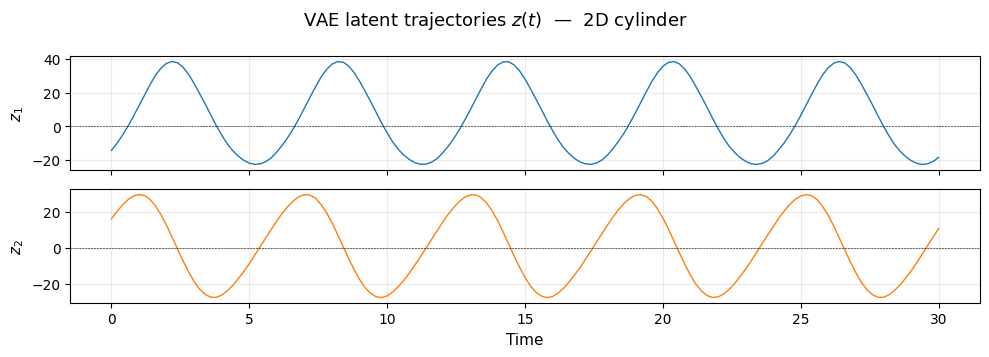

Saved to: vae_beta_0.00e+00_ld_2/latent_trajectories.png


In [10]:
import matplotlib.pyplot as plt

# td is still cropped to (nh, nw) — extract latent vectors before padding
latent = model.latent_space(td)   # (T, lat_dim)
latent_np = latent.cpu().numpy() if isinstance(latent, torch.Tensor) else np.array(latent)
print('Latent trajectory shape:', latent_np.shape)

fig, axes = plt.subplots(lat_dim, 1, figsize=(10, 1.8 * lat_dim), sharex=True)
axes = [axes] if lat_dim == 1 else axes

for i, ax in enumerate(axes):
    ax.plot(time, latent_np[:, i], lw=1.0, color=f'C{i}')
    ax.set_ylabel(f'$z_{{{i+1}}}$', fontsize=11)
    ax.axhline(0, color='k', lw=0.4, ls='--')
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Time', fontsize=11)
fig.suptitle('VAE latent trajectories $z(t)$  —  2D cylinder', fontsize=13)
plt.tight_layout()

latent_fig = os.path.join(RESUDIR, 'latent_trajectories.png')
plt.savefig(latent_fig, dpi=150, bbox_inches='tight')
plt.show()
print('Saved to:', latent_fig)

## Reconstruction and accuracy

After training we pass all snapshots through the encoder–decoder to obtain the reconstructed flow field. The reconstructed and training tensors are then padded back to the original grid size `(n0h, n0w)` so they can be compared with the raw data stored in the pyLOM dataset.

In [11]:
rec = model.reconstruct(td)                       # shape: (ntimesteps, C, nh, nw) tensor
rd  = pyLOM.NN.Dataset((rec,), (nh, nw))          # wrap reconstruction in NN Dataset

rd.pad(n0h, n0w)   # pad back to original size
td.pad(n0h, n0w)

# Add reconstructed and preprocessed fields back to the pyLOM dataset
d.add_field('urec', 1, rd[:,0,:,:].numpy().reshape((len(time), n0w * n0h)).T)
d.add_field('utra', 1, td[:,0,:,:].numpy().reshape((len(time), n0w * n0h)).T)

# Compute RMSE between reconstruction and mean-subtracted input
rmse = np.sqrt(np.mean((rd[:,0,:,:].numpy() - td[:,0,:,:].numpy())**2))
print('Reconstruction RMSE: %.6e' % rmse)

Recovered energy 99.98
Recovered mean 92.49
Recovered fluct 100.00


Reconstruction RMSE: 1.652468e-03


## Export to ParaView

The reconstructed field (`urec`), the original x-velocity (`VELOX`) and the mean-subtracted training field (`utra`) are written to disk in VTKHDF format so they can be visualised in ParaView.

In [12]:
pyLOM.io.pv_writer(
    m, d, 'reco',
    basedir  = RESUDIR,
    instants = np.arange(time.shape[0], dtype=np.int32),
    times    = time,
    vars     = ['urec', 'VELOX', 'utra'],
    fmt      = 'vtkh5'
)

## Visualisation

We plot the first snapshot of the reconstructed field and the mean-subtracted input field side by side to assess the visual quality of the reconstruction.

2026-03-25 17:41:30.064 (  60.567s) [    7FD4733FA000]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
/home/ubuntu/Tutorials/pyLOM/pyLowOrder/pyLOM/utils/plots.py:171: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  return ugrid.plot(**kwargs)


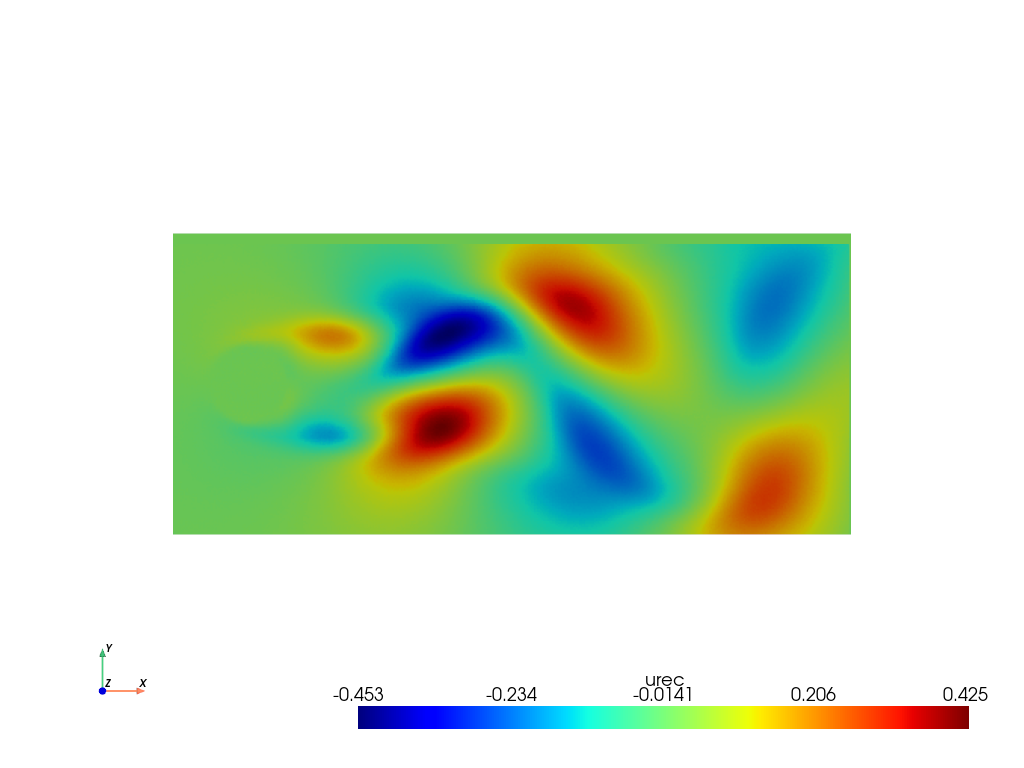

In [13]:
# Reconstructed field (instant 0)
pyLOM.NN.plotSnapshot(m, d, vars=['urec'], instant=0, component=0, cmap='jet', cpos='xy')

/home/ubuntu/Tutorials/pyLOM/pyLowOrder/pyLOM/utils/plots.py:171: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  return ugrid.plot(**kwargs)


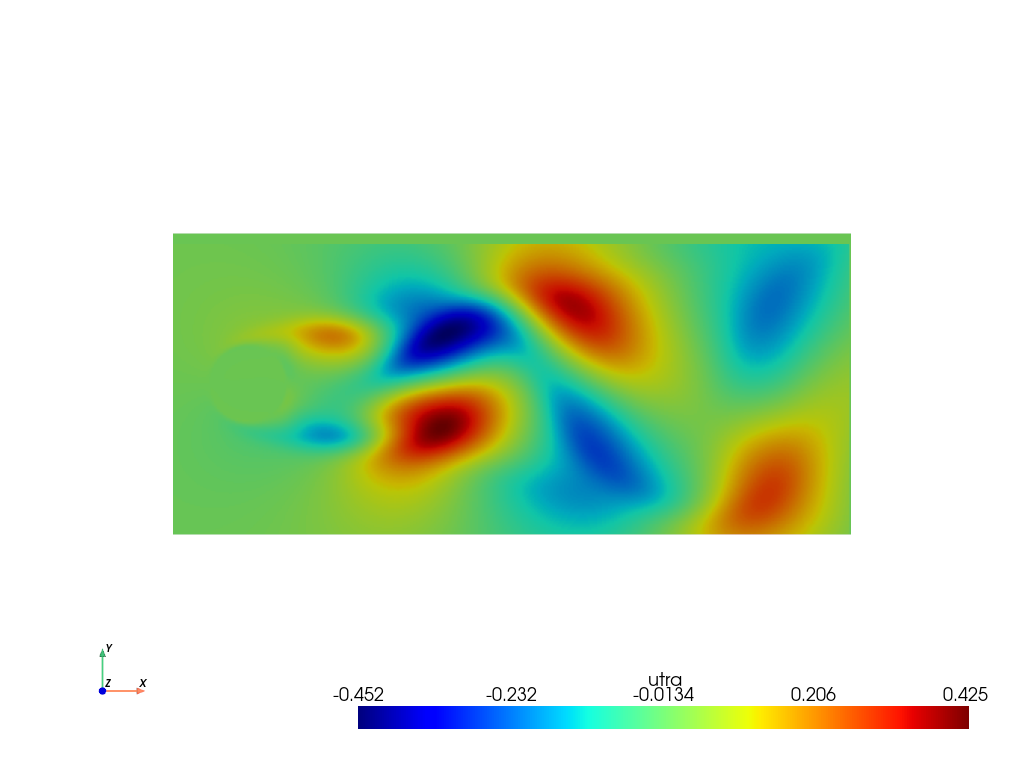

In [14]:
# Mean-subtracted training field (instant 0) — ground truth for the autoencoder
pyLOM.NN.plotSnapshot(m, d, vars=['utra'], instant=0, component=0, cmap='jet', cpos='xy')

## Timing summary

`pyLOM.cr_info()` prints a breakdown of the wall-clock time spent in each instrumented function, which is useful for profiling the workflow.

In [15]:
pyLOM.cr_info()


cr_info (mpi size: 1):
name VAE.fit                        n         1 tmin 5.495393e+01 tmax 5.495393e+01 tavg 5.495393e+01 tsum 5.495393e+01
name Writer.write                   n         1 tmin 4.189086e-01 tmax 4.189086e-01 tavg 4.189086e-01 tsum 4.189086e-01
name plots.pyvista_snap             n         2 tmin 7.921768e-02 tmax 3.139910e-01 tavg 1.966044e-01 tsum 3.932087e-01
name vtkh5IO.save_field             n       151 tmin 1.720937e-03 tmax 2.543206e-03 tavg 1.880104e-03 tsum 2.838957e-01
name Dataset.load                   n         1 tmin 2.455672e-01 tmax 2.455672e-01 tavg 2.455672e-01 tsum 2.455672e-01
name h5IO.load_dset                 n         1 tmin 2.455271e-01 tmax 2.455271e-01 tavg 2.455271e-01 tsum 2.455271e-01
name VAE.reconstruct                n         1 tmin 1.437206e-01 tmax 1.437206e-01 tavg 1.437206e-01 tsum 1.437206e-01
name NN.Dataset.__init__            n         2 tmin 2.639524e-02 tmax 5.990580e-02 tavg 4.315052e-02 tsum 8.630104e-02
name vtkh5IO.lin